# Cheng's ideational consistency: a size effect, not reach

This notebook is a runnable demo of the experiment **"Cheng's consistency: size effect, not reach"**.

Cheng et al. (2023, *ASR*) define **ideational consistency** as the cosine between a concept's neighbour co-usage
vector in year *t-1* and in year *t*. They report that consistent concepts get more next-year uptake: b ≈ .43, or
+53% per SD. The experiment rebuilds that measure on grounded OpenAlex topic co-usage for 12,499 EXP5 frame concepts
and 1,443 cohort concepts, then asks two questions:

1. **Test A (Cheng's panel design).** Does the volume effect replicate? How much of it survives a control for
   *current* size, log V(t)? (Full run: A1 +83%/SD, A2 +1.3%/SD, ratio 0.021, so **SIZE-DOMINATED**.)
2. **Test B (static early trait).** Net of the B5 size/growth/breadth baseline, does early consistency predict later
   cross-field **reach** (rarefied field richness O2r_m50) or **depth** (O1c/O1b/O3)? (Full run: reach partial
   Spearman -0.069 [-0.093, -0.047], depth ≈ 0, so a **REVERSAL** for reach.)

The original `method.py` is an orchestrator. It calls `lib/` modules step by step (S0-S8) over roughly 280k
concept-year rows cached from upstream experiments. This notebook keeps the original functions of those modules
(`cheng.py`, `panel_cheng.py`, `static_cheng.py`, `rq1stats.py`) nearly verbatim. It runs them on a **curated
100-concept subset** (`mini_demo_data.json`), which carries each concept's raw per-year HOME neighbour topic vectors,
so CONS is recomputed from scratch here.

> Everything here is *selection data, not confirmation*. With 100 concepts instead of ~7k, confidence intervals are
> much wider than in the full run. The full-run numbers are shown alongside for comparison.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# pyfixest — NOT pre-installed on Colab, always install (PPML with fixed effects, as in the original)
_pip('pyfixest==0.60.0')

# numpy, pandas, scipy, matplotlib, statsmodels — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'statsmodels==0.14.6')

## Imports
These are the imports from the original `method.py` plus the ones the `lib/` modules need
(`panel_cheng.py`, `static_cheng.py`, `rq1stats.py`). `matplotlib` is added for the final figure. As in the
original, BLAS runs one thread per process.

In [2]:
from __future__ import annotations

import os
import sys

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):   # one BLAS thread per process: the
    os.environ.setdefault(_v, "1")                                         # steps parallelise across processes
import time
from pathlib import Path

import math
import warnings

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata

import matplotlib.pyplot as plt

## Data loading
`mini_demo_data.json` holds 100 EXP5 frame concepts, stratified over the 8 field groups and the three EXP5 bodies
(DEV / OLD_HELDOUT / COHORT_2010_14). Each concept has:
- `home_vectors[t]`: the HOME-build **neighbour topic co-usage vector** v_t, with self topics removed (sparse
  `topics`/`counts`), plus `n_papers`, for t0..t0+10;
- `panel[t]`: grounded yearly volume `V`, plus the artifact's per-year `EMB` (PMI embeddedness analogue), `SOC`
  (prior co-author tie density) and `CONS_ref` (stored CONS, used for a check);
- static columns: the B5 baseline (`logvol, growth_c, offhome_share, entropy, reach`), the outcomes
  (`O2r_m50, O2r_resid, O1c, O1b, O3`) and `V_t0p2`, `V_t0p3`.

`metadata.full_run_headline_numbers` holds the full-run results, for comparison.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_kLBLH5WmvR9Y/round-5/experiment-14/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
EXAMPLES = data["datasets"][0]["examples"]
NT = data["metadata"]["n_topics_vocab"]            # size of the OpenAlex topic vocabulary (vector length)
HEAD = data["metadata"]["full_run_headline_numbers"]
print(f"{len(EXAMPLES)} concepts, topic vocabulary {NT}")
print(pd.Series([e["group"] for e in EXAMPLES]).value_counts().to_dict())

100 concepts, topic vocabulary 4516
{'BGM': 13, 'LIFEENV': 13, 'Eng': 13, 'CS': 13, 'SOC': 12, 'MATHDEC': 12, 'PHYS': 12, 'Med': 12}


## Configuration
Every tunable parameter is set here. The original values are in the comments. `N_BOOT_PANEL` is the number of
concept-cluster bootstrap draws for the Test A ratio. `N_BOOT_STATIC` is the number of concept bootstrap draws for the
Test B partial Spearman. The measure constants (`MIN_PAPERS`, `MIN_TOPICS`) and the variable lists are copied
verbatim from `lib/common.py`.

In [5]:
N_CONCEPTS = 100          # concepts used from the mini data (max 100; full run: 12,499 EXP5 + 1,443 cohort)
N_BOOT_PANEL = 500        # Test A ratio bootstrap draws   (original: N_BOOT_PANEL = 500)
N_BOOT_STATIC = 2000     # Test B psp bootstrap draws     (original: N_BOOT_STATIC = 2000)
SEED = 20260929           # original seed

# ---- verbatim from lib/common.py
MIN_PAPERS = 3                      # CONS / EMB defined iff >= 3 papers ...
MIN_TOPICS = 2                      # ... and >= 2 non-self topics in BOTH years (CONS) / in year t (EMB)
GROUP5 = {"CS": "CS+Eng", "Eng": "CS+Eng", "BGM": "BGM+Med", "Med": "BGM+Med", "PHYS": "PHYS",
          "LIFEENV": "LIFEENV", "SOC": "SOC", "MATHDEC": "MATHDEC"}
GROUPS5 = ["CS+Eng", "BGM+Med", "PHYS", "LIFEENV", "SOC"]
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
DEPTH = ["O1c", "O1b", "O3"]
REACH = ["O2r_m50", "O2r_resid"]
SELECTION_LABEL = "selection data, not confirmation"
PRIMARY = "EXP5_pooled"
OUTS = REACH + DEPTH

EXAMPLES = EXAMPLES[:N_CONCEPTS]

## S1: Cheng's consistency measure (`lib/cheng.py`)
For concept *c* and year *t*, **v_t[k]** is the number of year-*t* HOME papers of *c* tagged with topic *k*, where
*k* is not one of the concept's own "self" topics.

- **CONS(t) = cos(v_{t-1}, v_t).** It is defined only if both years have ≥ 3 papers and ≥ 2 non-self topics;
  otherwise it is NaN.
- **CONS_r** is Cheng's verbatim variant. It uses the cosine over the support of v_{t-1} only.

The functions below are copied verbatim from `lib/cheng.py`. The next cell rebuilds the dense vectors from the
sparse JSON and recomputes CONS for every concept-year.

In [6]:
# ----------------------------------------------------------------------------- measures (verbatim lib/cheng.py)
def cosine(u: np.ndarray, v: np.ndarray) -> float:
    nu, nv = float(np.sqrt(u @ u)), float(np.sqrt(v @ v))
    if nu == 0 or nv == 0:
        return 0.0
    return float(u @ v / (nu * nv))


def cons(v_prev: np.ndarray, v_cur: np.ndarray, n_prev: int, n_cur: int) -> tuple[float, float]:
    """(CONS, CONS_r). NaN unless both years have >= MIN_PAPERS papers and >= MIN_TOPICS non-self topics."""
    if n_prev < MIN_PAPERS or n_cur < MIN_PAPERS:
        return float("nan"), float("nan")
    if (v_prev > 0).sum() < MIN_TOPICS or (v_cur > 0).sum() < MIN_TOPICS:
        return float("nan"), float("nan")
    c = cosine(v_prev, v_cur)
    supp = v_prev > 0
    vr = np.where(supp, v_cur, 0.0)
    cr = cosine(v_prev, vr)
    return c, cr

**Per concept-year HOME features.** This cell stands in for the original `concept_measures()` loop (`build.py` /
`cheng.py`). That loop rebuilt v_t from the raw OpenAlex rows. Here v_t comes precomputed and self-topic filtered
from the JSON; that is the only change. `EMB` and `SOC` need the topic-PMI backbone and co-author lists, which are too
large for the demo, so the artifact's stored values are used for them. The last line checks that the recomputed CONS
matches the artifact's stored CONS.

In [7]:
t = time.time()
feat_rows, V_rows, fr_rows = [], [], []
for e in EXAMPLES:
    ci, t0 = e["ci"], e["t0"]
    fr_rows.append({"ci": ci, "t0": t0, "group": e["group"], "body": e["body"], "group5": e["group5"]})
    vecs = {}
    for y, hv in e["home_vectors"].items():
        v = np.zeros(NT)
        v[hv["topics"]] = hv["counts"]
        vecs[int(y)] = (v, hv["n_papers"])
    for y, pv in e["panel"].items():
        V_rows.append({"ci": ci, "year": int(y), "V": pv["V"]})
    for y in sorted(vecs):
        v, n_cur = vecs[y]
        r = {"ci": ci, "year": y, "build": "HOME", "n_papers": n_cur, "n_topics": int((v > 0).sum())}
        if y - 1 in vecs:
            vp, n_prev = vecs[y - 1]
            r["CONS"], r["CONS_r"] = cons(vp, v, int(n_prev), int(n_cur))
        else:
            r["CONS"], r["CONS_r"] = float("nan"), float("nan")
        pv = e["panel"].get(str(y), {})
        r["EMB"] = np.nan if pv.get("EMB") is None else pv["EMB"]
        r["SOC"] = np.nan if pv.get("SOC") is None else pv["SOC"]
        r["CONS_ref"] = np.nan if pv.get("CONS_ref") is None else pv["CONS_ref"]
        feat_rows.append(r)
feat = pd.DataFrame(feat_rows)
Vtab = pd.DataFrame(V_rows)
frame = pd.DataFrame(fr_rows)
chk = feat[(feat.year > feat.merge(frame, on="ci").t0) & (np.isfinite(feat.CONS) | np.isfinite(feat.CONS_ref))]
dev = np.nanmax(np.abs(chk.CONS - chk.CONS_ref)) if len(chk) else float("nan")
print(f"{len(feat)} concept-years, {np.isfinite(feat.CONS).sum()} with finite CONS; "
      f"max |CONS recomputed - artifact| = {dev:.2e} (JSON keeps 6 decimals) ({time.time() - t:.1f}s)")
feat.head()

1088 concept-years, 953 with finite CONS; max |CONS recomputed - artifact| = 5.00e-07 (JSON keeps 6 decimals) (0.0s)


,ci,year,build,n_papers,n_topics,CONS,CONS_r,EMB,SOC,CONS_ref
0,60,2003,HOME,21,22,NaN,NaN,0.753771,0.006581,0.645427
1,60,2004,HOME,48,41,0.673252,0.792527,0.829415,0.007136,0.673252
2,60,2005,HOME,52,44,0.764998,0.801900,0.779253,0.010503,0.764998
3,60,2006,HOME,45,48,0.836921,0.906261,0.928588,0.005176,0.836921
4,60,2007,HOME,41,55,0.684800,0.839724,0.690500,0.007286,0.684800


**Static early traits** (verbatim `build.static_table`). A concept's early trait is the mean of each measure over
years t0+1..t0+2. For example, `CONS_early_home` is the early consistency. Only the HOME build is in the demo data.
`n_authors` is not shipped, so its aggregation line is dropped.

In [8]:
MEAS = ["CONS", "CONS_r", "EMB", "SOC"]     # original: ["CONS", "CONS_r", "EMB", "EMB_cos", "SOC"]


def static_table(feat: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    f = feat.merge(meta[["ci", "t0"]], on="ci")
    f = f[(f.year >= f.t0 + 1) & (f.year <= f.t0 + 2)]
    g = f.groupby(["ci", "build"])[MEAS].mean().unstack("build")
    g.columns = [f"{m}_early_{b.lower()}" for m, b in g.columns]
    g = g.reset_index()
    # early support diagnostics (HOME build)
    fh = f[f.build == "HOME"].groupby("ci").agg(n_papers_early_home=("n_papers", "sum"),
                                                deg_early_home=("n_topics", "mean")).reset_index()
    return meta[["ci", "body", "t0", "group", "group5"]].merge(g, on="ci", how="left").merge(fh, on="ci", how="left")


cheng_static = static_table(feat, frame)
ref = pd.Series({e["ci"]: e["CONS_early_home_ref"] for e in EXAMPLES})
print("max |CONS_early_home - artifact| =",
      float(np.nanmax(np.abs(cheng_static.set_index("ci").CONS_early_home - ref))))
cheng_static.head()

max |CONS_early_home - artifact| = 4.981693845773627e-07


,ci,body,t0,group,group5,CONS_early_home,CONS_r_early_home,EMB_early_home,SOC_early_home,n_papers_early_home,deg_early_home
0,60,DEV,2003,BGM,BGM+Med,0.719125,0.797214,0.804334,0.008820,100,42.5
1,444,OLD_HELDOUT,2007,MATHDEC,MATHDEC,0.353218,0.465452,3.635420,0.000000,9,3.5
2,562,OLD_HELDOUT,2003,LIFEENV,LIFEENV,0.463777,0.661054,1.208817,0.006614,14,17.5
3,1422,OLD_HELDOUT,2006,SOC,SOC,0.215264,0.250387,1.797687,0.003677,15,8.0
4,1719,OLD_HELDOUT,2008,PHYS,PHYS,0.565355,0.687359,1.572033,0.002263,22,12.5


## S3: Test A, Cheng's replication panel (`lib/panel_cheng.py`)
The panel covers concept-years t0+1 ≤ t ≤ min(t0+10, 2021) with finite CONS. Every model is PPML on next-year
volume V(t+1) with CRV1 standard errors clustered by concept:

- **A1** (Cheng's spec): `V(t+1) ~ zCONS + zEMB + zSOC | age + year`
- **A1-NB**: the same model as an NB2 negative binomial with dummies. This is the closest match to Cheng's
  over-dispersed model.
- **A2**: A1 + log1p V(t), which adds the **current-size** control.
- **A3**: A2 with concept + year fixed effects.
- **RATIO** b_A2 / b_A1 on zCONS, with a concept-cluster bootstrap that uses the same draws for A1 and A2 (numpy
  Poisson IRLS).

The functions are verbatim. `panel_A` reads the in-memory tables instead of the parquet files.

In [9]:
XS_JOINT = ["zCONS", "zEMB", "zSOC"]


# ----------------------------------------------------------------------------- data
def panel_A(build: str) -> pd.DataFrame:
    fr = frame[["ci", "t0", "group", "body", "group5"]]              # original: EXP5/frame_concepts.csv
    f = feat[feat.build == build][["ci", "year", "CONS", "EMB", "SOC", "n_papers", "n_topics"]]
    V = Vtab[["ci", "year", "V"]]                                     # original: data/V_exp5.parquet
    d = f.merge(fr, on="ci")
    d = d[(d.year >= d.t0 + 1) & (d.year <= np.minimum(d.t0 + 10, 2021))]
    d = d.merge(V, on=["ci", "year"], how="left").merge(
        V.assign(year=V.year - 1).rename(columns={"V": "V_next"}), on=["ci", "year"], how="left")
    d = d[np.isfinite(d.CONS)].copy()
    d["age"] = d.year - d.t0
    d["logV"] = np.log1p(d.V)
    return d.reset_index(drop=True)


def zcols(d: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    d = d.copy()
    for c in cols:
        v = d[c].to_numpy(float)
        d["z" + c] = (v - np.nanmean(v)) / np.nanstd(v)
    return d

**Numpy Poisson IRLS and the cluster bootstrap of the ratio** (verbatim). Age and year enter as dummy columns. The
original splits the bootstrap seeds across worker processes. Here `workers=1`, so it runs sequentially with the same
seeds.

In [10]:
# ----------------------------------------------------------------------------- numpy Poisson IRLS (dummies FE)
def dummy_design(d: pd.DataFrame, xs: list[str], fe: list[str]) -> tuple[np.ndarray, list[str]]:
    cols = [np.ones(len(d))]
    names = ["_const"]
    for c in xs:
        cols.append(d[c].to_numpy(float))
        names.append(c)
    for f in fe:
        v = d[f].to_numpy()
        for u in np.unique(v)[1:]:
            cols.append((v == u).astype(float))
            names.append(f"{f}={u}")
    return np.column_stack(cols), names


def poisson_irls(X: np.ndarray, y: np.ndarray, iters: int = 100, tol: float = 1e-10) -> np.ndarray:
    mu = y.mean() + 0.1
    b = np.zeros(X.shape[1])
    b[0] = math.log(mu)
    eta = X @ b
    for _ in range(iters):
        mu = np.exp(np.clip(eta, -30, 30))
        z = eta + (y - mu) / mu
        XtW = X.T * mu
        H = XtW @ X
        try:
            bn = np.linalg.solve(H, XtW @ z)
        except np.linalg.LinAlgError:
            bn = np.linalg.lstsq(H, XtW @ z, rcond=None)[0]
        if np.max(np.abs(bn - b)) < tol:
            b = bn
            break
        b = bn
        eta = X @ b
    return b


def _boot_ratio_worker(args) -> list[tuple[float, float]]:
    X1, X2, y, cl_idx, seeds = args
    out = []
    for s in seeds:
        rng = np.random.default_rng(s)
        pick = rng.integers(0, len(cl_idx), len(cl_idx))
        rows = np.concatenate([cl_idx[p] for p in pick])
        b1 = poisson_irls(X1[rows], y[rows])[1]
        b2 = poisson_irls(X2[rows], y[rows])[1]
        out.append((b1, b2))
    return out


def cluster_index(ci: np.ndarray) -> list[np.ndarray]:
    order = np.argsort(ci, kind="stable")
    u, start = np.unique(ci[order], return_index=True)
    return np.split(order, start[1:])


def boot_ratio(d: pd.DataFrame, xs: list[str], n_boot: int, seed: int, workers: int) -> dict:
    """Cluster bootstrap of b_A1 and b_A2 on the first regressor (zCONS), same draws."""
    X1, _ = dummy_design(d, xs, ["age", "year"])
    X2, _ = dummy_design(d, xs + ["logV"], ["age", "year"])
    y = d.V_next.to_numpy(float)
    cl = cluster_index(d.ci.to_numpy())
    b1p, b2p = poisson_irls(X1, y)[1], poisson_irls(X2, y)[1]
    seeds = [seed + k for k in range(n_boot)]
    res = _boot_ratio_worker((X1, X2, y, cl, seeds))   # original: ProcessPoolExecutor over `workers` seed chunks
    B = np.array(res)
    ratio = B[:, 1] / B[:, 0]
    pr = b2p / b1p
    return {"b_A1_irls": b1p, "b_A2_irls": b2p, "ratio": pr,
            "ratio_ci": np.percentile(ratio, [2.5, 97.5]).tolist(), "ratio_boot_median": float(np.median(ratio)),
            "b_A1_ci_boot": np.percentile(B[:, 0], [2.5, 97.5]).tolist(),
            "b_A2_ci_boot": np.percentile(B[:, 1], [2.5, 97.5]).tolist(),
            "p_one_ratio_lt_0.5": float((np.sum(ratio >= 0.5) + 1) / (len(ratio) + 1)),
            "p_one_A1_gt_0": float((np.sum(B[:, 0] <= 0) + 1) / (len(B) + 1)),
            "n_boot": int(len(B)), "resampling_unit": "concept (cluster bootstrap)", "boot_b": B}

**Model wrappers** (verbatim): `pyfixest.fepois` for the PPML models and the statsmodels NB2 twin. `fit_A_set`
fits A1, A2, A3 and optionally A1-NB, and returns the point ratio b_A2/b_A1.

In [11]:
# ----------------------------------------------------------------------------- pyfixest wrappers
def fepois(d: pd.DataFrame, y: str, xs: list[str], fe: str) -> dict:
    import pyfixest as pf
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = pf.fepois(f"{y} ~ {' + '.join(xs)} | {fe}", data=d, vcov={"CRV1": "ci"})
    return summarize(fit, xs, d)


def summarize(fit, xs: list[str], d: pd.DataFrame) -> dict:
    co, se, pv = fit.coef(), fit.se(), fit.pvalue()
    ci = fit.confint()
    out = {"n_rows": int(fit._N), "n_concepts": int(d.ci.nunique()), "coef": {}}
    for x in xs:
        if x not in co.index:
            continue
        b = float(co[x])
        out["coef"][x] = {"b": b, "se": float(se[x]), "ci": [float(ci.loc[x].iloc[0]), float(ci.loc[x].iloc[1])],
                          "p": float(pv[x]), "pct_per_sd": math.exp(b) - 1,
                          "pct_ci": [math.exp(float(ci.loc[x].iloc[0])) - 1, math.exp(float(ci.loc[x].iloc[1])) - 1]}
    return out


def nb_fit(d: pd.DataFrame, xs: list[str]) -> dict:
    import statsmodels.api as sm
    X, names = dummy_design(d, xs, ["age", "year"])
    y = d.V_next.to_numpy(float)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m = sm.NegativeBinomial(y, X, loglike_method="nb2")
        try:
            r = m.fit(disp=0, maxiter=300, method="bfgs", cov_type="cluster", cov_kwds={"groups": d.ci.to_numpy()})
            how = "bfgs"
        except np.linalg.LinAlgError:
            # retry: Newton from the Poisson IRLS solution and alpha = 0.5
            sp0 = np.r_[poisson_irls(X, y), 0.5]
            r = m.fit(start_params=sp0, disp=0, maxiter=100, method="newton", cov_type="cluster",
                      cov_kwds={"groups": d.ci.to_numpy()})
            how = "newton (retry after singular bfgs)"
    out = {"n_rows": int(len(y)), "alpha": float(r.params[-1]), "converged": bool(r.mle_retvals.get("converged", True)),
           "optimizer": how, "coef": {}}
    for i, nm in enumerate(names):
        if nm in xs:
            b, s = float(r.params[i]), float(r.bse[i])
            out["coef"][nm] = {"b": b, "se": s, "ci": [b - 1.96 * s, b + 1.96 * s], "pct_per_sd": math.exp(b) - 1,
                               "p": float(2 * stats.norm.sf(abs(b / s)))}
    return out


# ----------------------------------------------------------------------------- test A
def fit_A_set(d: pd.DataFrame, xs: list[str], with_A3: bool = True, with_nb: bool = False) -> dict:
    out = {"A1": fepois(d, "V_next", xs, "age + year"),
           "A2": fepois(d, "V_next", xs + ["logV"], "age + year")}
    if with_A3:
        out["A3"] = fepois(d, "V_next", xs + ["logV"], "ci + year")
    if with_nb:
        try:
            out["A1_NB"] = nb_fit(d, xs)
        except (ValueError, np.linalg.LinAlgError) as e:
            out["A1_NB"] = {"error": repr(e)[:300]}
    b1 = out["A1"]["coef"].get("zCONS", {}).get("b", np.nan)
    b2 = out["A2"]["coef"].get("zCONS", {}).get("b", np.nan)
    out["ratio_point"] = b2 / b1 if b1 else float("nan")
    return out

**Run Test A** (the HOME part of `run_A`). The demo has only the HOME build. The by-body and by-group refits
(each group needs ≥ 30 concepts) and their DerSimonian-Laird pooling are left out at this sample size.

In [12]:
t = time.time()
build = "HOME"
d0 = panel_A(build)
d0 = d0[np.isfinite(d0.V_next)]
dj = zcols(d0.dropna(subset=["EMB", "SOC"]), ["CONS", "EMB", "SOC"])
dc = zcols(d0, ["CONS"])
A = {"n_rows_CONS": int(len(dc)), "n_rows_joint": int(len(dj)), "n_concepts_joint": int(dj.ci.nunique()),
     "share_rows_dropped_for_EMB_SOC": 1 - len(dj) / max(len(dc), 1),
     "CONS_mean": float(d0.CONS.mean()), "CONS_sd": float(d0.CONS.std())}
A["joint"] = fit_A_set(dj, XS_JOINT, with_A3=True, with_nb=True)
A["cons_only"] = fit_A_set(dc, ["zCONS"], with_A3=True, with_nb=True)
br = boot_ratio(dj, XS_JOINT, N_BOOT_PANEL, SEED, 1)
br["irls_vs_pyfixest_abs_diff_A1"] = abs(br["b_A1_irls"] - A["joint"]["A1"]["coef"]["zCONS"]["b"])
boot_b = br.pop("boot_b")
A["joint"]["ratio_boot"] = br
print(f"Test A ({A['n_rows_joint']} concept-years, {A['n_concepts_joint']} concepts) in {time.time() - t:.1f}s")
for m in ["A1", "A1_NB", "A2", "A3"]:
    c = A["joint"][m]["coef"]["zCONS"]
    print(f"  {m:5s} b(zCONS) = {c['b']:+.3f}  [{c['ci'][0]:+.3f}, {c['ci'][1]:+.3f}]  -> {100 * c['pct_per_sd']:+.1f}% per SD")
print(f"  RATIO b_A2/b_A1 = {br['ratio']:.3f}  boot CI {np.round(br['ratio_ci'], 3)}  ({br['n_boot']} draws); "
      f"|IRLS - pyfixest| = {br['irls_vs_pyfixest_abs_diff_A1']:.1e}")

Test A (937 concept-years, 100 concepts) in 1.8s
  A1    b(zCONS) = +0.733  [+0.327, +1.140]  -> +108.2% per SD
  A1_NB b(zCONS) = +0.465  [+0.268, +0.662]  -> +59.2% per SD
  A2    b(zCONS) = +0.005  [-0.021, +0.031]  -> +0.5% per SD
  A3    b(zCONS) = +0.018  [-0.012, +0.048]  -> +1.8% per SD
  RATIO b_A2/b_A1 = 0.007  boot CI [-0.045  0.062]  (500 draws); |IRLS - pyfixest| = 6.0e-12


## S4: Test B, the static early trait: reach vs depth (`lib/static_cheng.py`)
Test B uses the **partial Spearman** psp = Pearson(resid(rank x | Z), resid(rank y | Z)). Here Z holds rank(B5)
plus onset-year, field-group and body dummies. Ranks and residuals are recomputed inside every concept bootstrap
draw. Several outcomes share one draw, so a paired difference such as psp(O1c) - psp(O2r_m50) uses the same draws.

`static_frame` builds the analysis table from the JSON; the original merged EXP8/EXP10 parquet files. The rest of the
code is verbatim.

In [13]:
# ----------------------------------------------------------------------------- data
STATIC_COLS = ["ci", "t0", "group", "body", "name", "window_flag", "V_t0p2", "V_t0p3"] + B5 + OUTS


def static_frame() -> pd.DataFrame:
    df = pd.DataFrame([{k: e[k] for k in STATIC_COLS} for e in EXAMPLES])   # original: EXP8 + EXP10 parquet merges
    df["split"] = df.body
    s = cheng_static.drop(columns=["body", "t0", "group"])
    df = df.merge(s, on="ci", how="left", suffixes=("", "_st"))
    df["group5"] = df.group.map(GROUP5)
    df["logV_t0p2"] = np.log1p(df.V_t0p2)
    return df


def dummies(v: np.ndarray) -> np.ndarray:
    u = np.unique(v)
    if len(u) <= 1:
        return np.zeros((len(v), 0))
    return (v[:, None] == u[None, 1:]).astype(float)


def design(d: pd.DataFrame, cont: list[str] | None = None, groups: bool = True) -> tuple[np.ndarray, np.ndarray]:
    """(continuous covariates to be ranked, raw dummy matrix)."""
    cont = B5 if cont is None else cont
    cat = [dummies(d.t0.to_numpy())]
    if groups:
        cat.append(dummies(d.group.astype(str).to_numpy()))
    cat.append(dummies(d.body.astype(str).to_numpy()))
    if d.window_flag.nunique() > 1:
        cat.append(d[["window_flag"]].to_numpy(float))
    return d[cont].to_numpy(float), np.hstack(cat)

**The multi-outcome psp bootstrap engine** (verbatim). `resample_ranks` computes the average ranks of a resample
from bincounts, with no sort. `multi_boot` checks this fast path against the exact `scipy.rankdata` / `lstsq` path on
the first two draws. It raises if the two disagree by more than 1e-8.

In [14]:
# ----------------------------------------------------------------------------- multi-psp bootstrap engine
def _resid_corr(xr: np.ndarray, yr: np.ndarray, Br: np.ndarray, C: np.ndarray) -> np.ndarray:
    Z = np.hstack([np.ones((len(xr), 1)), Br, C])
    Yall = np.hstack([xr, yr])
    beta, *_ = np.linalg.lstsq(Z, Yall, rcond=None)
    R = Yall - Z @ beta
    R -= R.mean(0)
    s = R.std(0)
    s[s < 1e-12] = np.nan
    R /= s
    nx = xr.shape[1]
    return (R[:, :nx].T @ R[:, nx:]) / len(R)                      # [nx, ny] Pearson of residuals


def psp_multi(X: np.ndarray, Y: np.ndarray, B: np.ndarray, C: np.ndarray) -> np.ndarray:
    Br = rankdata(B, axis=0) if B.shape[1] else np.zeros((len(X), 0))
    return _resid_corr(rankdata(X, axis=0), rankdata(Y, axis=0), Br, C)


def unique_ids(M: np.ndarray) -> list[tuple[np.ndarray, int]]:
    """Per column: ids of the value-sorted unique values (so ranks of any resample follow from bincounts)."""
    out = []
    for j in range(M.shape[1]):
        _, inv = np.unique(M[:, j], return_inverse=True)
        out.append((inv.astype(np.int64), int(inv.max()) + 1))
    return out


def resample_ranks(uids: list[tuple[np.ndarray, int]], idx: np.ndarray) -> np.ndarray:
    """Average ranks (identical to scipy rankdata 'average') of every column within the resample idx, scaled by
    1/n. For unique value k with c_k copies: rank = cumsum(c)_k - (c_k - 1)/2. No sort needed."""
    n = len(idx)
    R = np.empty((n, len(uids)))
    for j, (u, U) in enumerate(uids):
        ui = u[idx]
        c = np.bincount(ui, minlength=U)
        avg = np.cumsum(c) - (c - 1) / 2.0
        R[:, j] = avg[ui] / n
    return R


def fast_corr(RX: np.ndarray, RY: np.ndarray, RB: np.ndarray, C: np.ndarray) -> np.ndarray:
    """Residual-correlation matrix via the pseudo-inverse of Z'Z (min-norm LS; exact projection even when the
    dummy block is rank deficient)."""
    Z = np.hstack([np.ones((len(RX), 1)), RB, C])
    V = np.hstack([RX, RY])
    ZtZ = Z.T @ Z
    beta = np.linalg.pinv(ZtZ, rcond=1e-12, hermitian=True) @ (Z.T @ V)
    R = V - Z @ beta
    R -= R.mean(0)
    s = R.std(0)
    s[s < 1e-12] = np.nan
    R /= s
    nx = RX.shape[1]
    return (R[:, :nx].T @ R[:, nx:]) / len(R)


def multi_boot(X: np.ndarray, Y: np.ndarray, B: np.ndarray, C: np.ndarray, n_boot: int, seed: int,
               check: bool = True) -> dict:
    ok = np.all(np.isfinite(X), 1) & np.all(np.isfinite(Y), 1) & np.all(np.isfinite(B), 1)
    X, Y, B, C = X[ok], Y[ok], B[ok], C[ok]
    n = len(X)
    if n < 30:
        return {"n": n, "est": np.full((X.shape[1], Y.shape[1]), np.nan), "boot": np.zeros((0, X.shape[1], Y.shape[1]))}
    keep = C.std(0) > 0
    est = psp_multi(X, Y, B, C[:, keep])                           # exact path (lstsq, scipy rankdata)
    ux, uy, ub = unique_ids(X), unique_ids(Y), unique_ids(B)
    rng = np.random.default_rng(seed)
    bs = np.empty((n_boot, X.shape[1], Y.shape[1]))
    max_dev = 0.0
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        bs[b] = fast_corr(resample_ranks(ux, i), resample_ranks(uy, i), resample_ranks(ub, i), C[i])
        if check and b < 2:                                         # fast path == exact path on the first draws
            Ci = C[i]
            ex = psp_multi(X[i], Y[i], B[i], Ci[:, Ci.std(0) > 0])
            max_dev = max(max_dev, float(np.nanmax(np.abs(ex - bs[b]))))
    if max_dev > 1e-8:
        raise ValueError(f"fast bootstrap path deviates from exact psp by {max_dev:.2e}")
    return {"n": n, "est": est, "boot": bs, "fast_path_max_dev": max_dev}


def summ(est: float, bs: np.ndarray, direction: int = -1) -> dict:
    bs = bs[np.isfinite(bs)]
    if not len(bs) or not np.isfinite(est):
        return {"rho": None, "ci": [None, None], "se": None}
    lo, hi = np.percentile(bs, [2.5, 97.5])
    return {"rho": float(est), "ci": [float(lo), float(hi)], "se": float(np.std(bs, ddof=1)),
            "p_one_pred": float((np.sum(direction * bs <= 0) + 1) / (len(bs) + 1)),
            "p_two": float(min(1.0, 2 * min((np.sum(bs <= 0) + 1) / (len(bs) + 1), (np.sum(bs >= 0) + 1) / (len(bs) + 1)))),
            "n_boot": int(len(bs))}

**Tasks** (verbatim).

- `task_trait` computes psp of the trait with the depth outcomes (O1c, O1b, O3), with the reach outcomes (O2r_m50,
  O2r_resid), and the paired depth-minus-reach differences.
- `task_volume` checks the **raw** association Cheng relies on: Spearman(CONS_early, V(t0+3)). It also gives its
  size-controlled partials.

In [15]:
def task_trait(args) -> dict:
    """One trait x one body: depth set (O1c, O1b, O3 own complete cases) and reach set (O2r_* complete cases, with
    the depth outcomes on the SAME rows for the paired differences)."""
    name, d, x, n_boot, seed, groups = args
    out = {"task": name, "x": x, "n_body": int(len(d))}
    B, C = design(d, groups=groups)
    xv = d[[x]].to_numpy(float)
    r1 = multi_boot(xv, d[DEPTH].to_numpy(float), B, C, n_boot, seed)
    r2 = multi_boot(xv, d[REACH + DEPTH].to_numpy(float), B, C, n_boot, seed + 1)
    res = {}
    for j, y in enumerate(DEPTH):
        res[y] = summ(r1["est"][0, j], r1["boot"][:, 0, j], direction=-1 if y == "O3" else 1)
        res[y]["n"] = r1["n"]
    for j, y in enumerate(REACH):
        res[y] = summ(r2["est"][0, j], r2["boot"][:, 0, j], direction=-1)
        res[y]["n"] = r2["n"]
    diffs = {}
    for a, b in [("O1c", "O2r_m50"), ("O1b", "O2r_m50"), ("O1c", "O2r_resid"), ("O3", "O2r_m50")]:
        ia, ib = (REACH + DEPTH).index(a), (REACH + DEPTH).index(b)
        e = r2["est"][0, ia] - r2["est"][0, ib]
        bs = r2["boot"][:, 0, ia] - r2["boot"][:, 0, ib]
        diffs[f"{a}-{b}"] = summ(e, bs, direction=1)
        diffs[f"{a}-{b}"]["n_common"] = r2["n"]
        diffs[f"{a}-{b}"]["psp_a_common"] = float(r2["est"][0, ia])
        diffs[f"{a}-{b}"]["psp_b_common"] = float(r2["est"][0, ib])
    out.update({"psp": res, "paired_diff": diffs})
    return out


def task_volume(args) -> dict:
    name, d, x, n_boot, seed = args
    xv, v3, v2 = d[x].to_numpy(float), d.V_t0p3.to_numpy(float), d.logV_t0p2.to_numpy(float)
    ok = np.isfinite(xv) & np.isfinite(v3) & np.isfinite(v2)
    xv, v3, v2 = xv[ok], v3[ok], v2[ok]
    n = len(xv)
    out = {"task": name, "x": x, "n": int(n)}
    if n < 30:
        return out
    rng = np.random.default_rng(seed)
    body_c = dummies(d.body.astype(str).to_numpy()[ok])
    Zc = np.hstack([v2[:, None], body_c])
    raw = float(stats.spearmanr(xv, v3)[0])
    ps = float(_resid_corr(rankdata(xv)[:, None], rankdata(v3)[:, None], rankdata(v2)[:, None], body_c)[0, 0])
    Bb, Cb = design(d[ok])
    ok5 = np.all(np.isfinite(Bb), 1)                               # B5 variant: complete B5 rows only
    x5, y5, Bb, Cb = xv[ok5], v3[ok5], Bb[ok5], Cb[ok5]
    n5 = len(x5)
    ps5 = float(psp_multi(x5[:, None], y5[:, None], Bb, Cb[:, Cb.std(0) > 0])[0, 0])
    br, bp, bp5 = np.empty(n_boot), np.empty(n_boot), np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        br[b] = stats.spearmanr(xv[i], v3[i])[0]
        k = body_c[i].std(0) > 0
        bp[b] = _resid_corr(rankdata(xv[i])[:, None], rankdata(v3[i])[:, None], rankdata(v2[i])[:, None],
                            body_c[i][:, k])[0, 0]
        j = rng.integers(0, n5, n5)
        Ci = Cb[j]
        bp5[b] = psp_multi(x5[j][:, None], y5[j][:, None], Bb[j], Ci[:, Ci.std(0) > 0])[0, 0]
    out["n_B5_variant"] = int(n5)
    out["B_raw_spearman_V_t0p3"] = summ(raw, br, direction=1)
    out["B_size_psp_V_t0p3_given_logV_t0p2"] = summ(ps, bp, direction=1)
    out["B_size_psp_V_t0p3_given_B5_dummies"] = summ(ps5, bp5, direction=1)
    return out

**Run Test B** on the primary body (EXP5 bodies pooled). `run_B` ran this on each body, each extra trait and each
field group, in parallel. The demo runs the primary trait `CONS_early_home` only, with the original seeds.

In [16]:
t = time.time()
df = static_frame()
d = df                                                    # EXP5_pooled = all three EXP5 bodies in the demo
bi = 0
rt = task_trait((f"{PRIMARY}|CONS_early_home", d, "CONS_early_home", N_BOOT_STATIC, SEED + 10 * bi, True))
rv = task_volume((f"{PRIMARY}|volume", d, "CONS_early_home", N_BOOT_STATIC, SEED + 10 * bi + 5))
print(f"Test B on {len(d)} concepts, {N_BOOT_STATIC} draws, in {time.time() - t:.1f}s")
print(f"  raw Spearman(CONS_early_home, V(t0+3)) = {rv['B_raw_spearman_V_t0p3']['rho']:+.3f} "
      f"{np.round(rv['B_raw_spearman_V_t0p3']['ci'], 3)}")
for y in OUTS:
    r = rt["psp"][y]
    print(f"  psp(CONS_early_home, {y:9s} | B5 + dummies) = {r['rho']:+.3f}  [{r['ci'][0]:+.3f}, {r['ci'][1]:+.3f}]  n={r['n']}")
pdiff = rt["paired_diff"]["O1c-O2r_m50"]
print(f"  paired diff psp(O1c) - psp(O2r_m50) = {pdiff['rho']:+.3f} {np.round(pdiff['ci'], 3)}")

Test B on 100 concepts, 2000 draws, in 2.7s
  raw Spearman(CONS_early_home, V(t0+3)) = +0.231 [0.034 0.418]
  psp(CONS_early_home, O2r_m50   | B5 + dummies) = -0.099  [-0.368, +0.169]  n=100
  psp(CONS_early_home, O2r_resid | B5 + dummies) = -0.118  [-0.382, +0.132]  n=100
  psp(CONS_early_home, O1c       | B5 + dummies) = -0.005  [-0.303, +0.254]  n=100
  psp(CONS_early_home, O1b       | B5 + dummies) = +0.070  [-0.199, +0.323]  n=100
  psp(CONS_early_home, O3        | B5 + dummies) = +0.055  [-0.127, +0.246]  n=100
  paired diff psp(O1c) - psp(O2r_m50) = +0.094 [-0.248  0.409]


## S8: Verdict rules applied to the demo (`lib/outputs.verdict`, subset)
These are the frozen rules for the predictions this demo can evaluate:
- **P1** (Cheng's volume effect): the raw Spearman > 0 and A1 b > 0, both with CIs above 0.
- **P2 / SIZE-DOMINATED**: the upper end of the ratio CI is < 0.5.
- **P3 / REVERSAL**: psp(O2r_m50) < 0 with its CI below 0.
- **P5 / DEPTH-REACH SPLIT**: the paired difference O1c - O2r_m50 > 0 with its CI above 0.

With 100 concepts the CIs are wide, so some labels may not fire even when the point estimates match the full run.

In [17]:
a1 = A["joint"]["A1"]["coef"]["zCONS"]
rb = A["joint"]["ratio_boot"]
raw = rv["B_raw_spearman_V_t0p3"]
p3 = rt["psp"]["O2r_m50"]
p5 = rt["paired_diff"]["O1c-O2r_m50"]
pred = {
    "P1": bool(raw["rho"] > 0 and raw["ci"][0] > 0 and a1["b"] > 0 and a1["ci"][0] > 0),
    "P2": bool(rb["ratio_ci"][1] < 0.5),
    "P3": bool(p3["rho"] < 0 and p3["ci"][1] < 0),
    "P5": bool(p5["rho"] > 0 and p5["ci"][0] > 0),
}
labels = []
if raw["rho"] > 0 and raw["ci"][0] > 0 and p3["rho"] < 0 and p3["ci"][1] < 0:
    labels.append("REVERSAL CONFIRMED (on selection data)")
if pred["P2"]:
    labels.append("SIZE-DOMINATED")
if pred["P5"]:
    labels.append("DEPTH-REACH SPLIT")
if p3["ci"][0] <= 0 <= p3["ci"][1]:
    labels.append("NULL-REVERSAL (CI of the reach partial includes 0)")
print("demo predictions:", pred)
print("demo verdict   :", labels)
print("full-run verdict: REVERSAL CONFIRMED (on selection data), REVERSAL REPLICATED, SIZE-DOMINATED, DEPTH-REACH SPLIT")

demo predictions: {'P1': True, 'P2': True, 'P3': False, 'P5': False}
demo verdict   : ['SIZE-DOMINATED', 'NULL-REVERSAL (CI of the reach partial includes 0)']
full-run verdict: REVERSAL CONFIRMED (on selection data), REVERSAL REPLICATED, SIZE-DOMINATED, DEPTH-REACH SPLIT


## Results: demo vs full run
The table puts the demo numbers (100 concepts) next to the full-run headline numbers (12,311 concepts in Test A and
6,913 in Test B). The figure has three panels:
1. Cheng's volume coefficient before (A1) and after (A2) the current-size control.
2. A forest plot of the early-trait partial Spearman for reach and depth.
3. The raw volume association that Cheng's result rests on.

                                    demo (100 concepts)  full run
quantity                                                         
A1 PPML %/SD (zCONS)                            108.184    83.101
A1-NB b (zCONS)                                   0.465     0.428
A2 PPML %/SD (+ log V(t))                         0.512     1.267
A3 PPML %/SD (+ concept FE)                       1.800     1.365
RATIO b_A2/b_A1                                   0.007     0.021
raw Spearman CONS_early vs V(t0+3)                0.231     0.256
psp reach O2r_m50                                -0.099    -0.069
psp depth O1c                                    -0.005    -0.000
psp depth O3                                      0.055    -0.001
paired diff O1c - O2r_m50                         0.094     0.035


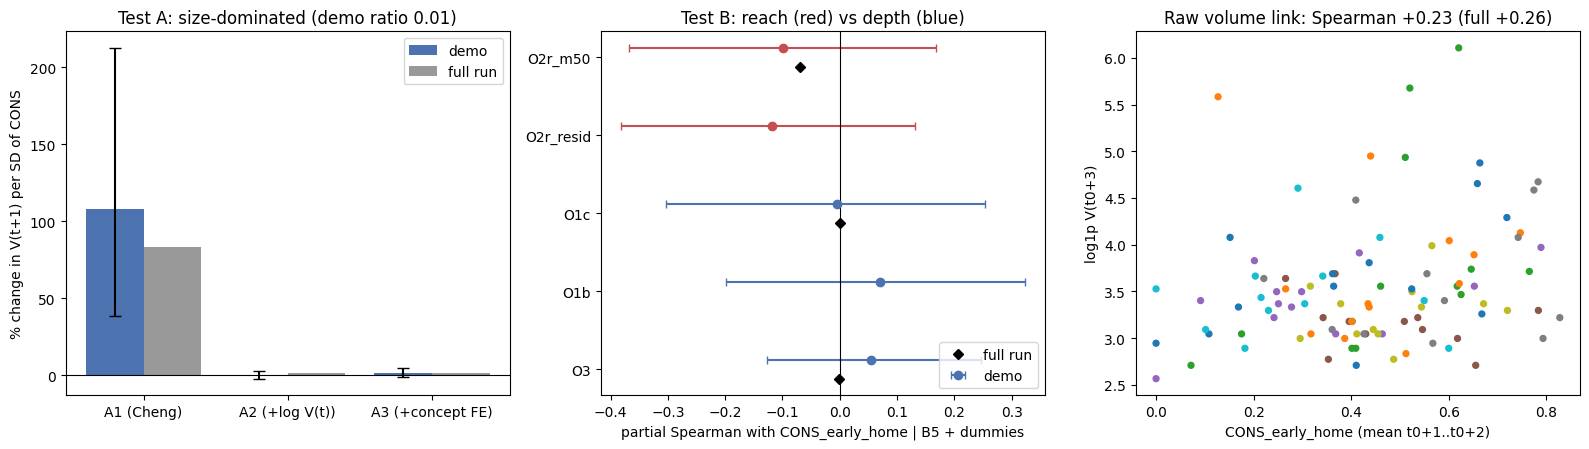

In [18]:
H = HEAD
P, S = "cheng_panel_models.json:builds.HOME.joint", "cheng_static.json:trait.EXP5_pooled|CONS_early_home"
rows = [
    ("A1 PPML %/SD (zCONS)", 100 * a1["pct_per_sd"], 100 * H[f"{P}.A1.coef.zCONS.pct_per_sd"]),
    ("A1-NB b (zCONS)", A["joint"]["A1_NB"]["coef"]["zCONS"]["b"] if "coef" in A["joint"]["A1_NB"] else np.nan,
     H[f"{P}.A1_NB.coef.zCONS.b"]),
    ("A2 PPML %/SD (+ log V(t))", 100 * A["joint"]["A2"]["coef"]["zCONS"]["pct_per_sd"],
     100 * H[f"{P}.A2.coef.zCONS.pct_per_sd"]),
    ("A3 PPML %/SD (+ concept FE)", 100 * A["joint"]["A3"]["coef"]["zCONS"]["pct_per_sd"],
     100 * H[f"{P}.A3.coef.zCONS.pct_per_sd"]),
    ("RATIO b_A2/b_A1", rb["ratio"], H[f"{P}.ratio_boot.ratio"]),
    ("raw Spearman CONS_early vs V(t0+3)", raw["rho"],
     H["cheng_static.json:volume.EXP5_pooled|volume.B_raw_spearman_V_t0p3.rho"]),
    ("psp reach O2r_m50", p3["rho"], H[f"{S}.psp.O2r_m50.rho"]),
    ("psp depth O1c", rt["psp"]["O1c"]["rho"], H[f"{S}.psp.O1c.rho"]),
    ("psp depth O3", rt["psp"]["O3"]["rho"], H[f"{S}.psp.O3.rho"]),
    ("paired diff O1c - O2r_m50", p5["rho"], H[f"{S}.paired_diff.O1c-O2r_m50.rho"]),
]
tab = pd.DataFrame(rows, columns=["quantity", "demo (100 concepts)", "full run"]).set_index("quantity")
print(tab.round(3).to_string())

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
# (1) size control collapses Cheng's coefficient
lab = ["A1 (Cheng)", "A2 (+log V(t))", "A3 (+concept FE)"]
dm = [100 * A["joint"][m]["coef"]["zCONS"]["pct_per_sd"] for m in ["A1", "A2", "A3"]]
de = [[100 * (A["joint"][m]["coef"]["zCONS"]["pct_per_sd"] - A["joint"][m]["coef"]["zCONS"]["pct_ci"][0]) for m in ["A1", "A2", "A3"]],
      [100 * (A["joint"][m]["coef"]["zCONS"]["pct_ci"][1] - A["joint"][m]["coef"]["zCONS"]["pct_per_sd"]) for m in ["A1", "A2", "A3"]]]
fu = [100 * H[f"{P}.{m}.coef.zCONS.pct_per_sd"] for m in ["A1", "A2", "A3"]]
xx = np.arange(3)
ax[0].bar(xx - 0.2, dm, 0.4, yerr=de, capsize=4, label="demo", color="#4C72B0")
ax[0].bar(xx + 0.2, fu, 0.4, label="full run", color="#999999")
ax[0].axhline(0, color="k", lw=0.8)
ax[0].set_xticks(xx, lab)
ax[0].set_ylabel("% change in V(t+1) per SD of CONS")
ax[0].set_title(f"Test A: size-dominated (demo ratio {rb['ratio']:.2f})")
ax[0].legend()
# (2) reach vs depth forest
ys = OUTS[::-1]
for k, y in enumerate(ys):
    r = rt["psp"][y]
    ax[1].errorbar(r["rho"], k + 0.12, xerr=[[r["rho"] - r["ci"][0]], [r["ci"][1] - r["rho"]]], fmt="o",
                   color="#C44E52" if y in REACH else "#4C72B0", capsize=3, label="demo" if k == 0 else None)
    key = f"{S}.psp.{y}.rho"
    if key in H:
        ax[1].plot(H[key], k - 0.12, "D", color="k", ms=5, label="full run" if y == "O3" else None)
ax[1].axvline(0, color="k", lw=0.8)
ax[1].set_yticks(range(len(ys)), ys)
ax[1].set_xlabel("partial Spearman with CONS_early_home | B5 + dummies")
ax[1].set_title("Test B: reach (red) vs depth (blue)")
ax[1].legend(loc="lower right")
# (3) raw volume association
ax[2].scatter(df.CONS_early_home, np.log1p(df.V_t0p3), c=df.group.astype("category").cat.codes, cmap="tab10", s=18)
ax[2].set_xlabel("CONS_early_home (mean t0+1..t0+2)")
ax[2].set_ylabel("log1p V(t0+3)")
ax[2].set_title(f"Raw volume link: Spearman {raw['rho']:+.2f} (full {H['cheng_static.json:volume.EXP5_pooled|volume.B_raw_spearman_V_t0p3.rho']:+.2f})")
plt.tight_layout()
plt.show()